# Evaluation of Whisper Models

## 1 Overview

Three OpenAI Whisper speech-to-text models Whisper-Tiny, Whisper-Base, and Whisper-Small [2] are compared in this notebook using the multilingual FLEURS dataset [1] in the four languages that the program supports: English, Malay, Chinese, and Tamil. Each split uses 200 recordings for each language.

Macro-averaged Character Error Rate (CER) is the main metric used to evaluate models on the validation split and choose the best candidate. Loading time, inference time, and macro Word Error Rate (WER) are also noted. On the reserved test split, only the chosen model is assessed. Because WER is meaningless for languages that are not word-segmented by spaces (such as Chinese), where a space based WER is close to 1.0 even when transcription is mostly accurate, CER was selected as the main statistic. There is no fine-tuning or training done.

## 2 Importing Libraries

This section imports the toolchain for the speech-to-text evaluation. The Transformers pipeline uses a single, consistent automatic-speech-recognition interface to execute each Whisper model, while the Hugging Face datasets library streams the multilingual FLEURS corpus and provides the audio decoding. Matplotlib creates the comparison graphic, NumPy and pandas manage the numerical work and the results tables, while unicodedata and re enable the meticulous text normalisation necessary for fair transcription grading. In order to prevent the lengthy generating logs from overpowering the notebook's own output, the Transformers logger is specifically set to error-only. Torch provides the tensor backend and GPU access.

In [1]:
# import required libraries
from pathlib import Path
import gc
import re
import time
import numpy as np
import pandas as pd
import torch
from transformers import pipeline
import unicodedata
import matplotlib.pyplot as plt
from datasets import Audio, load_dataset
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

c:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The notebook can download and cache the FLEURS audio, transcribe it using each Whisper size, and score the transcripts uniformly across four languages after these imports are set up. A minor readability choice that keeps the per-language findings apparent instead of hidden in generating warnings is to quiet the Transformers logger. The warning about the tqdm widget is only decorative. The shared settings, candidate models, and languages are fixed in the next section.

## 3 Evaluation Settings and Candidate Models

In order to compare the three Whisper sizes under the same circumstances, this section corrects all shared settings. The device is chosen, a special output folder is made, and a random seed is configured. The four supported languages are defined along with their FLEURS configuration name and the language code Whisper expects, as they differ and both are required, and three model variants Whisper-Tiny, Whisper-Base, and Whisper-Small are registered. To ensure that each language participates equally to the comparison, a set number of recordings per language is established.

In [2]:
# set seed is 42
SEED = 42

In [3]:
# seed NumPy for reproducibility
np.random.seed(SEED)
# seed PyTorch for reproducibility
torch.manual_seed(SEED)
# set device to 0 if cuda is available
device = 0 if torch.cuda.is_available() else -1

In [4]:
# output folder
output_folder = Path("outputs/whisper")
# create the folder
output_folder.mkdir(parents=True,exist_ok=True)

In [5]:
# define models
models = {
    # Whisper-Tiny model
    "Whisper-Tiny": {
        "model_id": "openai/whisper-tiny",
        "batch_size": 1
    },

    # Whisper-Base model
    "Whisper-Base": {
        "model_id": "openai/whisper-base",
        "batch_size": 1
    },

    # Whisper-Small model
    "Whisper-Small": {
        "model_id": "openai/whisper-small",
        "batch_size": 1
    }
}

In [6]:
# define languages
languages = {
    # English field
    "English": {
        "fleurs_config": "en_us",
        "whisper_language": "en"
    },

    # Malay field
    "Malay": {
        "fleurs_config": "ms_my",
        "whisper_language": "ms"
    },

    # Chinese field
    "Chinese": {
        "fleurs_config": "cmn_hans_cn",
        "whisper_language": "zh"
    },

    # Tamil field
    "Tamil": {
        "fleurs_config": "ta_in",
        "whisper_language": "ta"
    }
}

In [7]:
# sample per language
SAMPLES_PER_LANGUAGE = 200

Keeping the languages, their codes and the sample size in one place makes the comparison balanced and trivially easy to scale up or down, and pairing each language's FLEURS code with its Whisper code in a single structure prevents the subtle bug of transcribing a language with the wrong forced language token. The impact of model capacity on transcription quality, which is precisely the trade-off the application must make between accuracy and latency, may be isolated by comparing three sizes of the same model family. The notebook downloads the assessment audio after the settings are established.

## 4 Load Multilingual FLEURS Dataset

This section downloads the FLEURS validation recordings for each of the four languages, samples a fixed number per language with a fixed seed, writes the decoded audio to a local cache, and normalises every reference transcript so it can be compared fairly against a model's output. A single loader handles all four languages and returns one combined dataframe pairing each audio path with its normalised reference, language name and Whisper code, and the per-language counts are displayed to confirm the load.

In [8]:
# normalise text
def normalise_text(text):
    # text join
    text = unicodedata.normalize("NFKC",str(text)).lower()
    text = "".join(character if character.isalnum() or character.isspace() else " " for character in text)
    text = " ".join(text.split())
    return text.strip()

In [9]:
# flueurs audio folder
fleurs_audio_folder = Path("../../data/processed/fleurs_whisper")
fleurs_audio_folder.mkdir(parents=True,exist_ok=True)

In [10]:
# load fleurs split 
def load_fleurs_split(split_name,samples_per_language):
    # define records list
    records = []
    for language_name, language_details in languages.items():
        # load the dataset
        dataset = load_dataset("google/fleurs",language_details["fleurs_config"],split=split_name)
        # cast column
        dataset = dataset.cast_column("audio",Audio(decode=False))
        # compute dataset
        dataset = (dataset.shuffle(seed=SEED).select(range(min(samples_per_language,len(dataset)))))
        # compute language folder
        language_folder = (fleurs_audio_folder / split_name / language_details["fleurs_config"])
        # create folder
        language_folder.mkdir(parents=True,exist_ok=True)
        for index, sample in enumerate(dataset):
            # read audio
            audio_information = sample["audio"]
            # original path
            original_path = Path(audio_information["path"])
            # file suffix
            file_suffix = (original_path.suffix if original_path.suffix else ".wav")
            # audio path
            audio_path = (language_folder / f"{index:04d}{file_suffix}")

            if not audio_path.exists():
                with open(audio_path, "wb") as audio_file:
                    audio_file.write(audio_information["bytes"])

            # records append in the list
            records.append({
                "audio_path": audio_path,
                "reference": normalise_text(sample["transcription"]),
                "language": language_name,
                "whisper_language": (language_details["whisper_language"])
            })

    # return dataframe
    return pd.DataFrame(records)

In [11]:
# validation data 
validation_data = load_fleurs_split(split_name="validation",samples_per_language=SAMPLES_PER_LANGUAGE)
display(validation_data[["language","audio_path","reference"]].head())

,language,audio_path,reference
0,English,..\..\data\processed\fleurs_whisper\validation...,technology offers the solution with virtual fi...
1,English,..\..\data\processed\fleurs_whisper\validation...,there are a lot of social and political effect...
2,English,..\..\data\processed\fleurs_whisper\validation...,the final score was a one point victory 21 to ...
3,English,..\..\data\processed\fleurs_whisper\validation...,inland waterways can be a good theme to base a...
4,English,..\..\data\processed\fleurs_whisper\validation...,out of 1 400 people polled prior to the 2010 f...


In [12]:
# print language
display(validation_data["language"].value_counts())

language
English    200
Malay      200
Chinese    200
Tamil      200
Name: count, dtype: int64

**Analysis:** 

There are 800 recordings in the validation set, 200 in each of the four languages English, Malay, Chinese, and Tamil. By maintaining equal representation of the four languages, the macro-averaged mistake rates offer each language equal weight and are not dominated by the language that Whisper is already most proficient in (English).

Caching the decoded audio locally means the models can be re-run repeatedly without re-downloading FLEURS, which turns an expensive network operation into a one-off cost, and applying the same normalisation to the references here as will be applied to the hypotheses later is what makes the error rates fair rather than punishing a model for differences in punctuation or casing. Regardless of how well Whisper already handles each language, the macro-averages weight each language equally because the validation set is balanced at the configured number of recordings per language. The metrics and the transcription process are described in the following section.

## 5 Transcription and Multilingual ASR Metrics

This section defines exactly how transcripts are scored and produced. Word and character level edit distances are implemented directly and aggregated into Word Error Rate, Character Error Rate, sentence level rates and exact-match accuracy, and a runner transcribes the recordings language by language, forcing Whisper into the correct language for each group so it never has to guess. The scoring is clear and auditable when the error rates are implemented openly instead of importing a black-box scorer.

In [13]:
# word error counts
def word_error_counts(reference, hypothesis):
    # reference words
    reference_words = normalise_text(reference).split()
    # hypothesis words
    hypothesis_words = normalise_text(hypothesis).split()
    # rows
    rows = len(reference_words) + 1
    # columns
    columns = len(hypothesis_words) + 1
    # distance
    distance = [[0] * columns for _ in range(rows)]
    for row in range(rows):
        distance[row][0] = row

    for column in range(columns):
        distance[0][column] = column

    for row in range(1, rows):
        for column in range(1, columns):
            # compute substitution cost
            substitution_cost = (0 if reference_words[row - 1] == hypothesis_words[column - 1] else 1)
            # distance row column
            distance[row][column] = min(distance[row - 1][column] + 1, distance[row][column - 1] + 1, distance[row - 1][column - 1] + substitution_cost)
    return (distance[-1][-1], len(reference_words))

In [14]:
# character error counts
def character_error_counts(reference, hypothesis):
    # reference text
    reference_text = (normalise_text(reference).replace(" ", ""))
    # compute hypothesis text
    hypothesis_text = (normalise_text(hypothesis).replace(" ", ""))
    # reference characters
    reference_characters = list(reference_text)
    # hypothesis characters
    hypothesis_characters = list(hypothesis_text)
    # rows
    rows = len(reference_characters) + 1
    # columns
    columns = len(hypothesis_characters) + 1
    # build distance list
    distance = [[0] * columns for _ in range(rows)]
    for row in range(rows):
        distance[row][0] = row

    for column in range(columns):
        distance[0][column] = column

    for row in range(1, rows):
        for column in range(1, columns):
            # compute substitution cost
            substitution_cost = (0 if reference_characters[row - 1] == hypothesis_characters[column - 1] else 1)
            # distance row column
            distance[row][column] = min(distance[row - 1][column] + 1, distance[row][column - 1] + 1, distance[row - 1][column - 1] + substitution_cost)
    return (distance[-1][-1], len(reference_characters))

In [15]:
# calculate asr metrics
def calculate_asr_metrics(references,transcriptions):
    total_word_errors = 0
    total_words = 0
    total_character_errors = 0
    total_characters = 0
    exact_matches = 0
    # sentence wers list
    sentence_wers = []
    # sentence cers list
    sentence_cers = []
    for reference, transcription in zip(references,transcriptions):
        # word error count
        word_errors, words = word_error_counts(reference,transcription)
        # compute character errors characters
        character_errors, characters = (character_error_counts(reference,transcription))
        # accumulate into total word errors
        total_word_errors += word_errors
        # accumulate into total words
        total_words += words
        # accumulate into total character errors
        total_character_errors += (character_errors)
        # accumulate into total characters
        total_characters += characters
        # sentence wers append in list
        sentence_wers.append(word_errors / words if words else 0)
        # sentence cers append in list
        sentence_cers.append(character_errors / characters if characters else 0)
        # normalise text
        if normalise_text(reference) == normalise_text(transcription):
            exact_matches += 1

    # return the results dictionary
    return {
        "WER": (total_word_errors / total_words if total_words else 0),
        "CER": (total_character_errors / total_characters if total_characters else 0),
        "Average Sentence WER": (np.mean(sentence_wers)),
        "Average Sentence CER": (np.mean(sentence_cers)),
        "Exact Match Accuracy": (exact_matches / len(references) if references else 0)
    }

In [16]:
# run whisper models
def run_whisper_model(model_details, data):
    # model id
    model_id = model_details["model_id"]
    # batch size
    batch_size = model_details["batch_size"]
    # loading start
    loading_start = time.perf_counter()
    # transcriber
    transcriber = pipeline(task="automatic-speech-recognition",model=model_id,device=device)

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # loading time
    loading_time = (time.perf_counter() - loading_start)

    # transcriptions list
    transcriptions = [None] * len(data)

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference start
    inference_start = time.perf_counter()

    for whisper_language, language_data in data.groupby( "whisper_language", sort=False):
        print(f"  Transcribing language: {whisper_language}")
        # compute audio paths
        audio_paths = (language_data["audio_path"].astype(str).tolist())
        # outputs
        outputs = transcriber(audio_paths,batch_size=batch_size,return_timestamps=True,generate_kwargs={"language": whisper_language,"task": "transcribe"})

        for dataframe_index, output in zip(language_data.index,outputs):
            # position
            position = data.index.get_loc(dataframe_index)
            # transcription positions
            transcriptions[position] = (normalise_text(output["text"]))

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # inference time
    inference_time = (time.perf_counter() - inference_start)

    # run garbage collection
    gc.collect()

    # if a GPU is available
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # return the results dictionary
    return {"transcriptions": transcriptions,"loading_time": loading_time,"inference_time": inference_time}

The key methodological choice of this notebook is to provide both WER and CER. Word-based WER is unreliable for languages that are not segmented by spaces, especially Chinese, where it can approach 1.0 even for a largely correct transcript, so CER is the metric used when the two disagree. By enforcing the language per group, pure transcription quality is isolated and language identification is removed as a source of confusion. Normalising every hypothesis with the same function used on the references keeps the comparison fair. The models can be assessed once the metrics and runner have been established.

## 6 Model Evaluation on Validation Data

Each of the three Whisper models is run over the validation recordings in this stage. In order to compare the accuracy and cost of the three sizes under a single technique, WER and CER are calculated per language and then macro-averaged, while loading and inference time are recorded. The per-language detail that a single global number would obscure is preserved by scoring each language before averaging.

In [17]:
# validation results list
validation_results = []
# validation language results list
validation_language_results = []
# validation transcriptions
validation_transcriptions = {}

In [18]:
for model_name, model_details in models.items():
    print(f"\nEvaluating {model_name}...")
    # evaluation
    evaluation = run_whisper_model(model_details,validation_data)
    # read transcriptions
    transcriptions = evaluation["transcriptions"]
    # validation transcriptions
    validation_transcriptions[model_name] = (transcriptions)
    # predictions series
    prediction_series = pd.Series(transcriptions,index=validation_data.index)
    # language cers list
    language_cers = []
    # language wers list
    language_wers = []
    for language_name in languages.keys():
        # compute language mask
        language_mask = (validation_data["language"] == language_name)
        # compute language references
        language_references = (validation_data.loc[language_mask,"reference"].tolist())
        # compute language predictions
        language_predictions = (prediction_series.loc[language_mask].tolist())
        # compute language metrics
        language_metrics = (calculate_asr_metrics(language_references,language_predictions))
        # language cers append to list
        language_cers.append(language_metrics["CER"])
        # language wers append to list
        language_wers.append(language_metrics["WER"])

        # validation lanague results append to list
        validation_language_results.append({
            "Model": model_name,
            "Language": language_name,
            "WER": language_metrics["WER"],
            "CER": language_metrics["CER"],
            "Average Sentence WER": (language_metrics["Average Sentence WER"]),
            "Average Sentence CER": (language_metrics["Average Sentence CER"]),
            "Exact Match Accuracy": (language_metrics["Exact Match Accuracy"])
        })
        print(f"  {language_name}: WER={language_metrics['WER']:.4f}, CER={language_metrics['CER']:.4f}")
    # macro cer float
    macro_cer = float(np.mean(language_cers))
    # macro wer float
    macro_wer = float(np.mean(language_wers))
    # validaiton results append to list
    validation_results.append({
        "Model": model_name,
        "Macro WER": macro_wer,
        "Macro CER": macro_cer,
        "Loading Time": (evaluation["loading_time"]),
        "Processing Time": (evaluation["inference_time"]),
        "ms per Recording": (evaluation["inference_time"] / len(validation_data) * 1000)
    })
    print(f"  Macro CER: {macro_cer:.4f}")


Evaluating Whisper-Tiny...
  Transcribing language: en
  Transcribing language: ms
  Transcribing language: zh
  Transcribing language: ta
  English: WER=0.1285, CER=0.0578
  Malay: WER=0.8798, CER=0.4555
  Chinese: WER=1.0000, CER=0.3942
  Tamil: WER=2.7610, CER=2.2174
  Macro CER: 0.7812

Evaluating Whisper-Base...
  Transcribing language: en
  Transcribing language: ms
  Transcribing language: zh
  Transcribing language: ta
  English: WER=0.0976, CER=0.0447
  Malay: WER=0.3641, CER=0.1099
  Chinese: WER=1.0000, CER=0.3745
  Tamil: WER=0.8536, CER=0.6368
  Macro CER: 0.2915

Evaluating Whisper-Small...
  Transcribing language: en
  Transcribing language: ms
  Transcribing language: zh
  Transcribing language: ta
  English: WER=0.0648, CER=0.0298
  Malay: WER=0.1951, CER=0.0637
  Chinese: WER=0.9994, CER=0.2149
  Tamil: WER=0.4376, CER=0.3090
  Macro CER: 0.1544


In [19]:
# validation results dataframe
validation_results_df = pd.DataFrame(validation_results)
validation_language_results_df = (pd.DataFrame(validation_language_results))

Only the validation split is used at this stage, and macro-CER is the primary metric because it remains meaningful across all four languages, including the non-space segmented one, whereas macro-WER does not. Logging inference time alongside accuracy captures the central trade-off, since the largest model is both the most accurate and the slowest. The analysis that follows explains the per-language and per-model numbers. Until a model is selected, the reserved test split remains unchanged.

## 7 Comparing and Selecting Best Model

This part illustrates the comparison, ranks the three models according to macro-CER, and chooses the best option. The measure explanation above directly leads to ranking on macro-CER instead of macro-WER.

In [20]:
# compute validation results df
validation_results_df = (validation_results_df.sort_values(by="Macro CER",ascending=True).reset_index(drop=True))
validation_results_df

,Model,Macro WER,Macro CER,Loading Time,Processing Time,ms per Recording
0,Whisper-Small,0.424232,0.154355,2.218458,4721.973528,5902.466910
1,Whisper-Base,0.578836,0.291474,3.179417,2333.047871,2916.309839
2,Whisper-Tiny,1.192325,0.781213,2.458894,5800.887846,7251.109807


In [21]:
# validation language results
validation_language_results_df

,Model,Language,WER,CER,Average Sentence WER,Average Sentence CER,Exact Match Accuracy
0,Whisper-Tiny,English,0.128469,0.057752,0.128622,0.057200,0.28
1,Whisper-Tiny,Malay,0.879796,0.455507,0.886664,0.463589,0.00
2,Whisper-Tiny,Chinese,1.000000,0.394154,1.000000,0.385155,0.00
3,Whisper-Tiny,Tamil,2.761037,2.217440,2.984200,2.391894,0.00
4,Whisper-Base,English,0.097608,0.044673,0.096633,0.043739,0.36
5,Whisper-Base,Malay,0.364100,0.109926,0.368597,0.114058,0.03
6,Whisper-Base,Chinese,1.000000,0.374530,1.000000,0.360023,0.00
7,Whisper-Base,Tamil,0.853636,0.636765,0.921711,0.690444,0.00
8,Whisper-Small,English,0.064833,0.029831,0.063233,0.029012,0.49
9,Whisper-Small,Malay,0.195063,0.063706,0.206928,0.069498,0.10


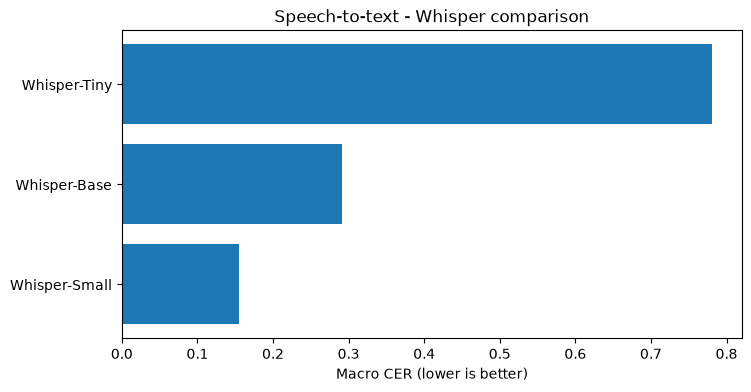

In [22]:
# bar chart for whisper comparison
plt.figure(figsize=(8, 4))
plt.barh(validation_results_df["Model"], validation_results_df["Macro CER"])
plt.xlabel("Macro CER (lower is better)")
plt.title("Speech-to-text - Whisper comparison")
plt.show()

**Analysis:** 

With model size, error decreases linearly. Whisper-Base (0.2915), Whisper-Tiny (0.7812), and Whisper-Small (0.1544) have the lowest macro-CER and macro-WER, respectively (0.4242, 0.5788, 1.1923). Whisper-Small performs best in English (CER 0.0298) and Malay (0.0637) and worst in Tamil (0.3090) and Chinese (0.2149). The near-1.0 Chinese WER for each model is an artifact of using a word-based measure to score a non-space-segmented language, which is why the models are ranked using CER rather than WER. Whisper-Small is chosen because it falls within the application's non-real-time check-in budget, even if larger models are slower.

In [23]:
# selected model name and details
selected_model_name = validation_results_df.loc[0,"Model"]
selected_model_details = models[selected_model_name]

In [24]:
# print statements
print("Selected multilingual Whisper model:",selected_model_name)
print("Validation Macro CER:",round(validation_results_df.loc[0,"Macro CER"],4))
print("Validation Macro WER:",round(validation_results_df.loc[0,"Macro WER"],4))

Selected multilingual Whisper model: Whisper-Small
Validation Macro CER: 0.1544
Validation Macro WER: 0.4242


The test results show generalisation rather than tuning since the chosen model then proceeds to the next test split unchanged. The decision also includes an explicit accuracy-versus-latency judgment the selected size is the most accurate that still fits the application's non-real-time check-in budget because error decreases monotonically with model size across all four languages. That decision on held-out data is confirmed in the following section.

## 8 Final Test Evaluation

In this stage, the reserved FLEURS test split is loaded, transcribed using the chosen model, and its macro-averaged and per-language WER and CER are calculated. The test and validation splits are directly comparable because they are loaded and assessed using the same loader and metrics.

In [25]:
# testing data
testing_data = load_fleurs_split(split_name="test",samples_per_language=SAMPLES_PER_LANGUAGE)

In [26]:
# total test recordings
print("\nTotal test recordings:",len(testing_data))


Total test recordings: 800


In [27]:
# value counts
display(testing_data["language"].value_counts())

language
English    200
Malay      200
Chinese    200
Tamil      200
Name: count, dtype: int64

In [28]:
# test evaluation and transcriptions
test_evaluation = run_whisper_model(selected_model_details,testing_data)
test_transcriptions = test_evaluation["transcriptions"]

  Transcribing language: en
  Transcribing language: ms
  Transcribing language: zh
  Transcribing language: ta


In [29]:
# test language results list
test_language_results = []

In [30]:
# test prediction series
test_prediction_series = pd.Series(test_transcriptions,index=testing_data.index)

In [31]:
# test language cers list
test_language_cers = []
# test language wers list
test_language_wers = []

In [32]:
for language_name in languages.keys():
    # language mask
    language_mask = (testing_data["language"] == language_name)
    # compute language references
    language_references = (testing_data.loc[language_mask,"reference"].tolist())
    # compute language predictions
    language_predictions = (test_prediction_series.loc[language_mask].tolist())
    # language metrics calculate
    language_metrics = calculate_asr_metrics(language_references,language_predictions)
    # test language cers append to list
    test_language_cers.append(language_metrics["CER"])
    # test language wers append to list
    test_language_wers.append(language_metrics["WER"])
    # test language results append to list
    test_language_results.append({
        "Language": language_name,
        "WER": language_metrics["WER"],
        "CER": language_metrics["CER"],
        "Average Sentence WER": (language_metrics["Average Sentence WER"]),
        "Average Sentence CER": (language_metrics["Average Sentence CER"]),
        "Exact Match Accuracy": (language_metrics["Exact Match Accuracy"])
    })

In [33]:
# test language results dataframe
test_language_results_df = pd.DataFrame(test_language_results)

In [34]:
# calculate cer and wer
test_macro_cer = float(np.mean(test_language_cers))
test_macro_wer = float(np.mean(test_language_wers))

In [35]:
# test results dataframe
test_results_df = pd.DataFrame([{
    "Model": selected_model_name,
    "Macro WER": test_macro_wer,
    "Macro CER": test_macro_cer,
    "Loading Time": (test_evaluation["loading_time"]),
    "Processing Time": (test_evaluation["inference_time"]),
    "ms per Recording": (test_evaluation["inference_time"] / len(testing_data) * 1000)
}])

In [36]:
# test results dataframe
test_results_df

,Model,Macro WER,Macro CER,Loading Time,Processing Time,ms per Recording
0,Whisper-Small,0.451779,0.180142,2.166483,5215.8742,6519.84275


In [37]:
# test language results dataframe
test_language_results_df

,Language,WER,CER,Average Sentence WER,Average Sentence CER,Exact Match Accuracy
0,English,0.064335,0.024442,0.064955,0.024506,0.425
1,Malay,0.175813,0.051402,0.177134,0.051984,0.110
2,Chinese,0.999288,0.207204,0.999269,0.203726,0.000
3,Tamil,0.567679,0.437520,0.553624,0.417763,0.000


**Analysis:** 

Whisper-Small's macro-CER of 0.1803 and macro-WER of 0.4517 on the reserved test split closely match its validation macro-CER of 0.1544, indicating consistent generalisation. The pattern is as follows Chinese (0.2072) and Tamil (0.4371) are the least accurately transcribed languages, while English (CER 0.0244) and Malay (0.0524) are the most. The exact-match accuracy is low for Malay (0.110) and high for English (0.425), but the CER for Chinese is still far more revealing than its 1.0 WER. These findings support the use of Whisper-Small as the multilingual transcription front-end that feeds the text-emotion model into the application.

Because the test recordings played no part in selection, these are the notebook's final, unbiased transcription figures and the best available proxy for how the model will handle real multilingual check-in speech. The decision generalises rather than fits the validation sample, as evidenced by the strong agreement between the validation and test macro-CER, which is covered below. Additionally, the per-language split highlights the model's strong and weak points, which downstream components need to take into account. All results are retained in the final section.

## 9 Saving Results

In order to retain each figure for the report and enable replication of the experiment, the model comparison, the per-language results, and the transcriptions themselves are finally written to CSV. The transcription errors can be examined qualitatively later if the raw transcriptions, not simply the scores, are saved.

In [38]:
# test predictions dataframe
test_predictions_df = pd.DataFrame({
    "Language": testing_data["language"],
    "Audio Path": testing_data["audio_path"],
    "Reference": testing_data["reference"],
    "Transcription": test_transcriptions
})

In [39]:
# test predictions dataframe
test_predictions_df.head()

,Language,Audio Path,Reference,Transcription
0,English,..\..\data\processed\fleurs_whisper\test\en_us...,its renown for being an epicenter of luxury be...,this renown for being at the center of luxury ...
1,English,..\..\data\processed\fleurs_whisper\test\en_us...,in fact it is not easy to find at all even if ...,in fact it is not easy to find at all even if ...
2,English,..\..\data\processed\fleurs_whisper\test\en_us...,the smaller the rossby number the less active ...,the smaller the raspy number the less active t...
3,English,..\..\data\processed\fleurs_whisper\test\en_us...,there is no universal definition for which man...,there is no universal definition for which man...
4,English,..\..\data\processed\fleurs_whisper\test\en_us...,built by the egyptians in the third century bc...,built by the egyptians in the 3rd century bce ...


In [40]:
# save to CSV
validation_results_df.to_csv(output_folder / "whisper_model_comparison.csv", index=False)
validation_language_results_df.to_csv(output_folder / "whisper_validation_language_results.csv", index=False)
test_results_df.to_csv(output_folder / "selected_whisper_model_test_results.csv", index=False)
test_language_results_df.to_csv(output_folder / "selected_whisper_model_language_results.csv", index=False)
test_predictions_df.to_csv(output_folder / "selected_whisper_model_transcriptions.csv", index=False)

In [41]:
# print statements
print("Selected multilingual Whisper model:",selected_model_name)

Selected multilingual Whisper model: Whisper-Small


The transcription experiment is finished and repeatable once the results are written, and the figures in the report can be linked to saved files. Without rerunning the models, keeping the transcriptions enables a subsequent error analysis, such as determining whether the Tamil errors are concentrated in specific phonemes or loanwords. The model selected to transcribe check-ins prior to text-emotion analysis is named in the conclusion that follows, which also summarises the results.

## 10 Conclusion

The multilingual FLEURS validation split between English, Malay, Chinese, and Tamil was used to compare three Whisper models. Whisper-Small was chosen as the final speech-to-text model because it outperformed Whisper-Base (0.2915) and Whisper-Tiny (0.7812) with the lowest validation macro-CER of 0.1544.

Whisper-Small achieved macro-CER of 0.1803 and macro-WER of 0.4517 on the reserved test split, which is comparable to its validation findings. According to the proportion of each language in Whisper's pretraining, it transcribed English and Malay the best and Chinese and Tamil the worst. Because word-based WER is meaningless for non spac segmented Chinese, where it remains close to 1.0 despite mostly correct output, CER was used as the main statistic throughout.

Thus, each audio will be transcribed using Whisper-Small in the final multimodal wellbeing-monitoring application before being analysed by the text-emotion model. To make runtime manageable while maintaining representativeness, the comparison was restricted to the four supported languages and 200 recordings per language per split.

## 11 References

[1] A. Conneau et al., "FLEURS: few-shot learning evaluation of universal representations of speech," 2022. [Online]. Available: https://arxiv.org/abs/2205.12446. [Accessed: 1 August 2026].

[2] A. Radford, J. W. Kim, T. Xu, G. Brockman, C. McLeavey, and I. Sutskever, "Robust speech recognition via large-scale weak supervision," 2022. [Online]. Available: https://arxiv.org/abs/2212.04356. [Accessed: 1 August 2026].